# Compare power scans

Overlay the model curves of several pump-power scans to read off the effect of a configuration change.

In [1]:
TITLE = "POLARIZATION_ANGLE_COMPARE__(MADHU)"

# {label: power-scan directory}.  A label is whatever varies between the scans.
SCANS = {
    "20deg": "data/Jun25/POWERSCAN__20deg/2026-06-25_14-42-09_g2_heralded_virtual",
    "30deg": "data/Jun25/POWERSCAN__30deg/2026-06-25_15-19-41_g2_heralded_virtual",
    "40deg": "data/Jun25/POWERSCAN__40deg/2026-06-25_15-46-01_g2_heralded_virtual",
    "50deg": "data/Jun25/POWERSCAN__50deg/2026-06-25_16-05-25_g2_heralded_virtual",
    "60deg": "data/Jun25/POWERSCAN__60deg/2026-06-25_16-34-51_g2_heralded_virtual",
    "70deg": "data/Jun25/POWERSCAN__70deg/2026-06-25_17-05-42_g2_heralded_virtual",
    "80deg": "data/Jun25/POWERSCAN__80deg/2026-06-25_17-29-25_g2_heralded_virtual",
}

HARMONICS = (3, 4, 5)
TAU_IN_NS = 4.0
# One OR several g2 methods ('delay' | 'direct' | 'heralded'). With several, each plot
# shows them side-by-side (single plots, shared y-axis) or overlaid in the same panel
# (grids). The first is the analyzers' primary method.
G2_METHODS = ["delay", "heralded"]
G2_METHOD  = G2_METHODS[0]

# optional dense intensity scan per scan, for a smooth K(n): {label: dir}
DENSE = {
#     "20deg": "data/Jun25/POWERSCAN__20deg/2026-06-25_14-52-17_intensity_scan",
#     "30deg": "data/Jun25/POWERSCAN__30deg/2026-06-25_15-30-01_intensity_scan",
#     "40deg": "data/Jun25/POWERSCAN__40deg/2026-06-25_15-56-08_intensity_scan",
#     "50deg": "data/Jun25/POWERSCAN__50deg/2026-06-25_16-15-57_intensity_scan",
#     "60deg": "data/Jun25/POWERSCAN__60deg/2026-06-25_16-45-18_intensity_scan",
#     "70deg": "data/Jun25/POWERSCAN__70deg/2026-06-25_17-15-50_intensity_scan",
#     "80deg": "data/Jun25/POWERSCAN__80deg/2026-06-25_17-39-30_intensity_scan",
}
MALUS = {"p_max": 112.044, "theta0": 88.268, "offset": 6.186, "factor": 2.0, "branch": "below"}

In [2]:
INTERACTIVE = True
try:
    if not INTERACTIVE:
        raise ImportError
    import ipympl  # noqa: F401
    get_ipython().run_line_magic('matplotlib', 'widget')
    print('Backend: ipympl widget (interactive - drag to pan, scroll to zoom)')
except (ImportError, AttributeError):
    try:
        get_ipython().run_line_magic('matplotlib', 'inline')
    except (NameError, AttributeError):
        pass
    print('Backend: inline (static PNGs)')
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "core.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS_DIR = ROOT / "results"
print("Project root:", ROOT)

Backend: ipympl widget (interactive - drag to pan, scroll to zoom)
Project root: /Users/simon.wtmn/Desktop/Quantum_SHHG


## 1. Build one analyzer per scan

In [3]:
from src.report import discover_power_scan, discover_runs, PowerScanComparisonReport
from src.powerscan import PowerScanAnalyzer

analyzers = {}
for label, rel in SCANS.items():
    runs = discover_power_scan(ROOT / rel)
    dense = discover_runs(ROOT / DENSE[label]) if label in DENSE else None
    analyzers[label] = PowerScanAnalyzer(
        runs, harmonics=HARMONICS, tau_in_ns=TAU_IN_NS, g2_method=G2_METHOD,
        intensity_runs=dense, malus=(MALUS if dense else None))
    print(f"  {label:10s}: {len(runs)} powers "
          f"({analyzers[label].I0.min():g}-{analyzers[label].I0.max():g} mW)"
          f"{' + dense K(n)' if analyzers[label].has_dense else ''}")

  20deg     : 4 powers (20-80 mW)
  30deg     : 4 powers (20-80 mW)
  40deg     : 4 powers (20-80 mW)
  50deg     : 4 powers (20-80 mW)
  60deg     : 4 powers (20-80 mW)
  70deg     : 4 powers (20-80 mW)
  80deg     : 4 powers (20-80 mW)


## 2. Build the comparison report

One `PowerScanComparisonReport` drives everything; `c = rep.comp` is the shortcut every
plot below is built from. Each comparison figure then gets **its own cell** (section 3) so you
can tweak that plot's arguments independently — `dpi`, `ylim`, `harmonics`, … — and re-run just
that one cell. `rep.save(fig, name)` displays the figure **and** writes `<name>.png` flat under
`results/<sample>/<TITLE>/<date>/` (no `compare/` subfolder).

In [4]:
rep = PowerScanComparisonReport(analyzers, title=TITLE, results_root=RESULTS_DIR,
                                harmonics=HARMONICS)
c = rep.comp

PowerScanComparisonReport 'POLARIZATION_ANGLE_COMPARE__(MADHU)': 7 scans (20deg, 30deg, 40deg, 50deg, 60deg, 70deg, 80deg)
  -> results: /Users/simon.wtmn/Desktop/Quantum_SHHG/results/CdTe110/POLARIZATION_ANGLE_COMPARE___MADHU/2026-06-25


## 3. Comparison plots

One plot per cell — edit a cell's arguments (`dpi`, `ylim`, `harmonics`, …) and re-run just that
one. **Colour = scan** (compact colour-only legend on the right); **marker / linestyle = harmonic
or R pair** (small inset legend inside the axes).

### g2(0) vs power (colour = scan, marker = harmonic)

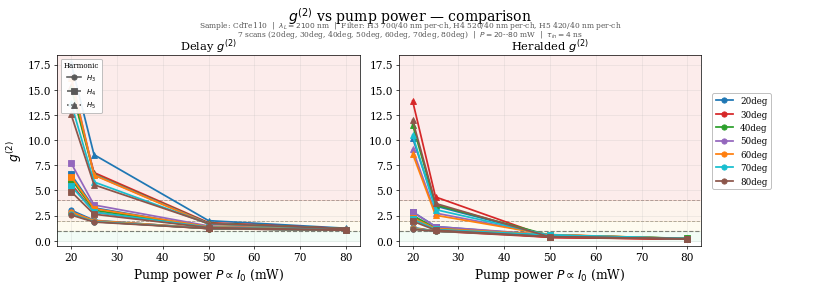

In [5]:
fig, _ = c.plot_g2_vs_power(harmonics=HARMONICS, methods=G2_METHODS, ylim=None)
rep.save(fig, "g2_vs_power", dpi=500)

### Inferred pump excess sigma^2 = g2_0 - 1 (headline comparison)

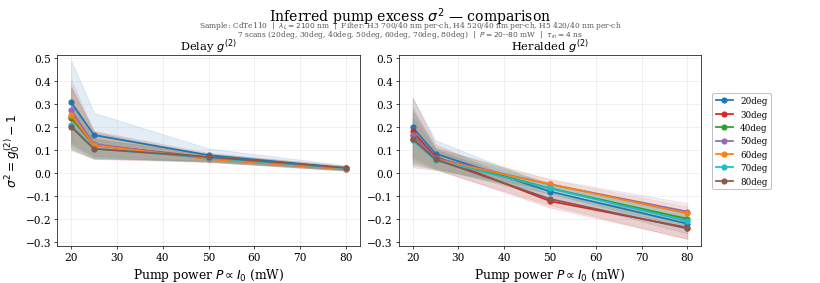

In [6]:
fig, _ = c.plot_inferred_sigma2(slope="local", harmonics=HARMONICS, include_cross=True, ylim=None, methods=G2_METHODS)
rep.save(fig, "inferred_sigma2", dpi=500)

### g2(0) vs power — every detector pair (one panel per pair, overlaying every scan)

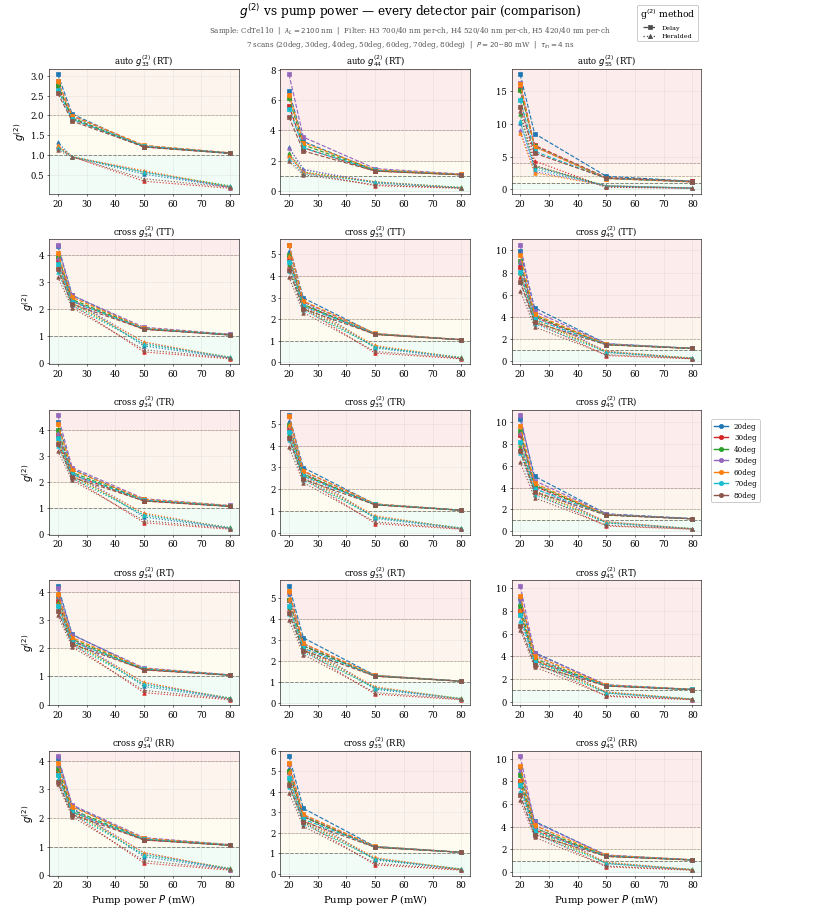

In [7]:
fig, _ = c.plot_g2_grid_vs_power(harmonics=HARMONICS, ylim=None, methods=G2_METHODS)
rep.save(fig, "g2_grid_vs_power", dpi=500)

### Cauchy-Schwarz R vs power (colour = scan, marker = cross pair)

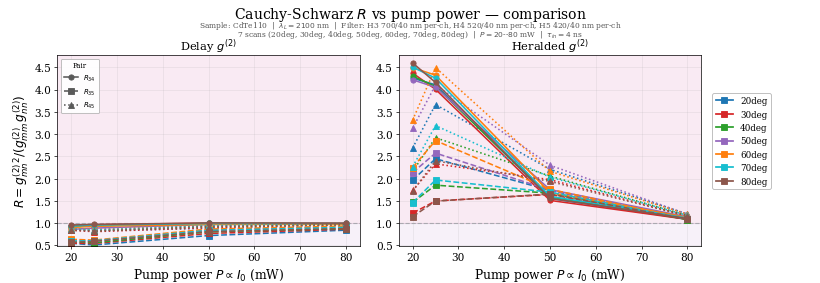

In [8]:
fig, _ = c.plot_R_vs_power(harmonics=HARMONICS, ylim=None, methods=G2_METHODS)
rep.save(fig, "R_vs_power", dpi=500)

### Cauchy-Schwarz R vs power — every cross pair (overlaying every scan)

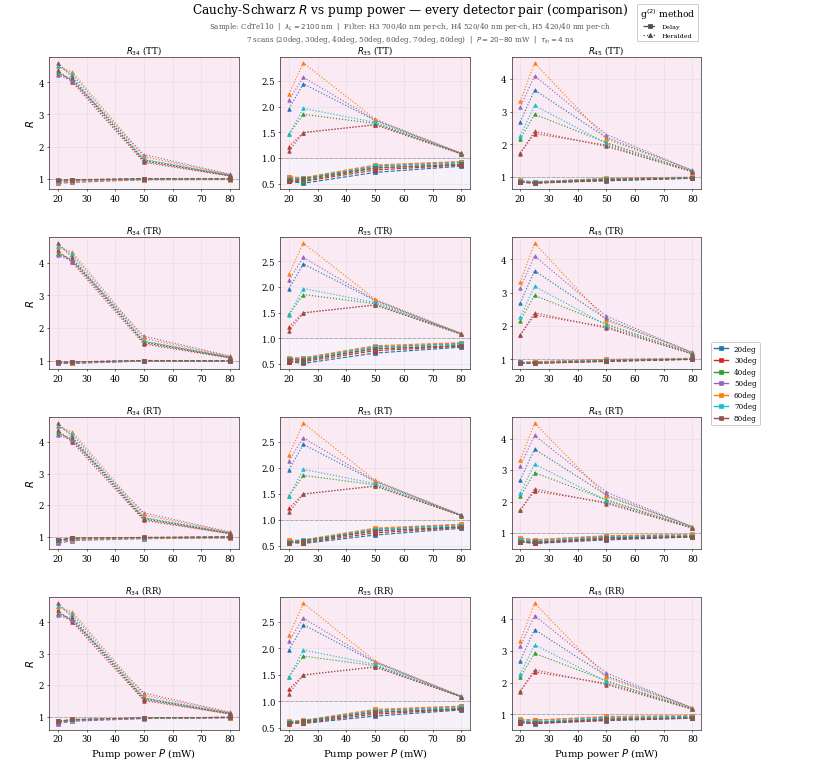

In [9]:
fig, _ = c.plot_R_grid_vs_power(harmonics=HARMONICS, ylim=None, methods=G2_METHODS)
rep.save(fig, "R_grid_vs_power", dpi=500)

### Harmonic intensity scaling (colour = scan, linestyle = harmonic)

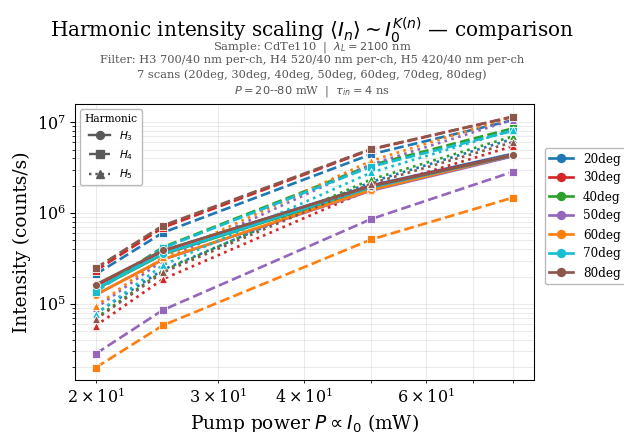

In [10]:
fig, _ = c.plot_intensity_scaling(harmonics=HARMONICS, xlim=None, ylim=None)
rep.save(fig, "intensity_scaling", dpi=500)

### Effective nonlinearity K(n) vs power

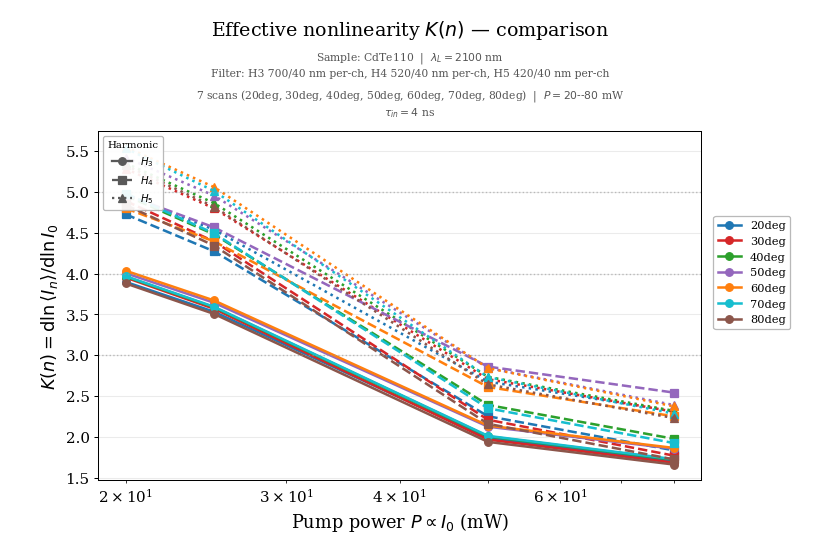

In [11]:
fig, _ = c.plot_local_slope(harmonics=HARMONICS, xlim=None, ylim=None)
rep.save(fig, "local_slope", dpi=300)

### Overview dashboard (2x2)

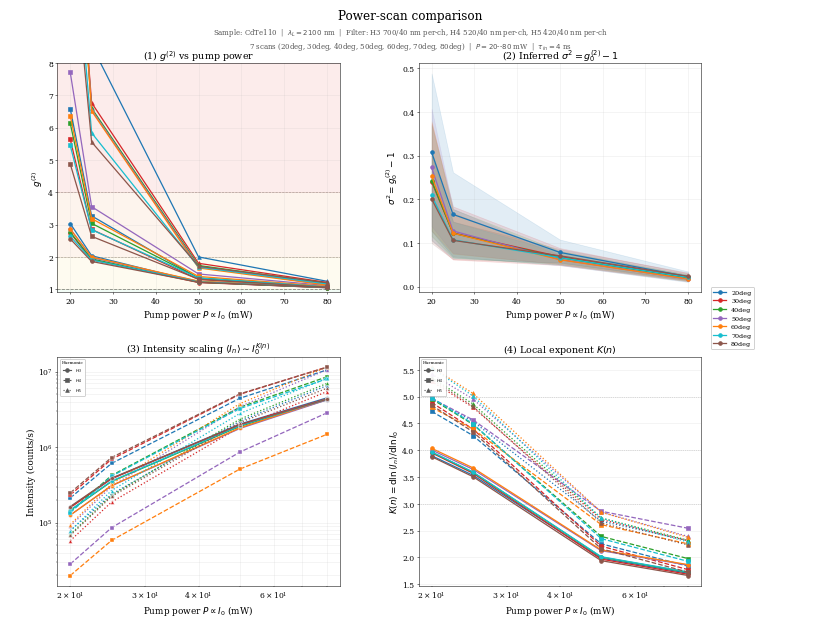

In [12]:
fig, _ = c.plot_overview(slope="local", harmonics=HARMONICS, g2_ylim=(0.9, 8), sigma2_ylim=None)
rep.save(fig, "overview", dpi=500)

## 4. Quick zoom

Drag / scroll on any figure above to zoom, or re-render one comparison with explicit limits
(e.g. a tighter `ylim`) — shown interactively, not re-saved.

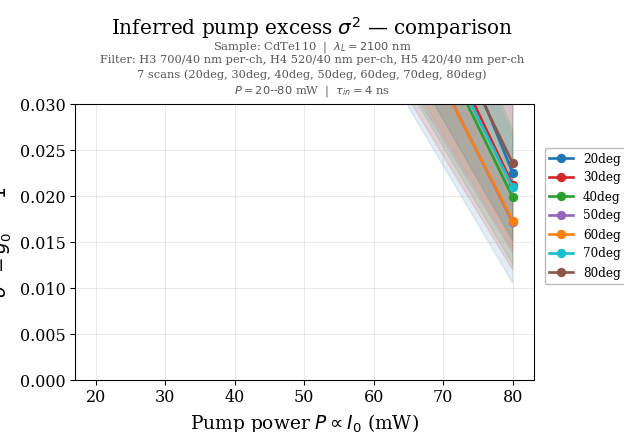

In [13]:
fig, _ = c.plot_inferred_sigma2(harmonics=HARMONICS, ylim=(0, 0.03))
rep._display(fig)